In [1]:
import os, json, random, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
from collections import Counter
from tqdm import tqdm
from gensim.models import Word2Vec
from torchcrf import CRF
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); np.random.seed(42); random.seed(42)
print(f"Device: {device}")
if device.type == 'cuda': print(f"GPU: {torch.cuda.get_device_name(0)}")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


Device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [2]:
DATA_DIR = '.'
SAVE_DIR = './dl_all_models_bio_crf'

ASPECTS = ["CAMERA","FEATURES","PERFORMANCE","DESIGN","PRICE",
           "GENERAL","SCREEN","BATTERY","STORAGE","SER&ACC"]
SENTIMENTS = ["POSITIVE","NEUTRAL","NEGATIVE"]
LABEL_NAMES = [f"{a}#{s}" for a in ASPECTS for s in SENTIMENTS]
NUM_LABELS = 30
LABEL2ID = {n:i for i,n in enumerate(LABEL_NAMES)}

# BIO TAG SYSTEM: O + B-label + I-label = 61 tags
O_TAG = 0
BIO_TAGS = ['O']
for label in LABEL_NAMES:
    BIO_TAGS.append(f'B-{label}')  # Begin
    BIO_TAGS.append(f'I-{label}')  # Inside

NUM_TAGS = len(BIO_TAGS)  # 61
TAG2ID = {t:i for i,t in enumerate(BIO_TAGS)}

def get_bio_ids(label_name):
    return TAG2ID[f'B-{label_name}'], TAG2ID[f'I-{label_name}']

MAX_LEN = 128
MIN_FREQ = 2
W2V_DIM = 150
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
PATIENCE = 7

print(f"✅ BIO Tag System: {NUM_TAGS} tags")

✅ BIO Tag System: 61 tags


In [3]:
# ============================================================
# CONVERT CHARACTER SPANS -> BIO TOKEN TAGS
# ============================================================
def text_to_bio_tags(text, spans, max_len):
    words = text.lower().split()[:max_len]
    positions = []
    pos = 0
    text_lower = text.lower()
    for w in words:
        idx = text_lower.find(w, pos)
        if idx == -1: idx = pos
        positions.append((idx, idx + len(w)))
        pos = idx + len(w)
    
    sorted_spans = sorted(spans, key=lambda s: s[1]-s[0])
    tags = [O_TAG] * max_len
    
    for start_char, end_char, label_str in sorted_spans:
        if label_str not in LABEL2ID: continue
        b_tag, i_tag = get_bio_ids(label_str)
        first_token = True
        for t_idx in range(len(words)):
            t_start, t_end = positions[t_idx]
            if t_start < end_char and t_end > start_char:
                if first_token:
                    tags[t_idx] = b_tag
                    first_token = False
                else:
                    tags[t_idx] = i_tag
    return tags, len(words)

def load_bio_data(filepath):
    texts, all_tags, sent_labels, lengths = [], [], [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line.strip())
            text = item['text']
            texts.append(text)
            spans = []
            sent = [0] * NUM_LABELS
            for s, e, label in item['labels']:
                if label in LABEL2ID:
                    sent[LABEL2ID[label]] = 1
                    spans.append((s, e, label))
            tags, length = text_to_bio_tags(text, spans, MAX_LEN)
            all_tags.append(tags)
            sent_labels.append(sent)
            lengths.append(length)
    return texts, all_tags, sent_labels, lengths

print("Loading & converting to BIO...")
train_texts, train_tags, train_sent, train_lens = load_bio_data(os.path.join(DATA_DIR, 'train.jsonl'))
dev_texts, dev_tags, dev_sent, dev_lens = load_bio_data(os.path.join(DATA_DIR, 'dev.jsonl'))
test_texts, test_tags, test_sent, test_lens = load_bio_data(os.path.join(DATA_DIR, 'test.jsonl'))
print(f"Train: {len(train_texts)} | Dev: {len(dev_texts)} | Test: {len(test_texts)}")

Loading & converting to BIO...
Train: 7785 | Dev: 1112 | Test: 2225


In [4]:
PAD_IDX = 0; UNK_IDX = 1
all_sentences = [t.lower().split() for t in train_texts + dev_texts + test_texts]
print(f"Training Word2Vec ({W2V_DIM}d)...")
w2v = Word2Vec(all_sentences, vector_size=W2V_DIM, window=5, min_count=MIN_FREQ, workers=4, epochs=20, sg=1, seed=42)

word2idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for i, w in enumerate(w2v.wv.index_to_key): word2idx[w] = i + 2
VOCAB_SIZE = len(word2idx)

emb_matrix = np.random.normal(0, 0.1, (VOCAB_SIZE, W2V_DIM)).astype(np.float32)
emb_matrix[PAD_IDX] = 0
for w, idx in word2idx.items():
    if w in w2v.wv: emb_matrix[idx] = w2v.wv[w]

print(f"Vocab: {VOCAB_SIZE}")
def tokenize(text, max_len):
    words = text.lower().split()[:max_len]
    seq = [word2idx.get(w, UNK_IDX) for w in words]
    length = max(len(seq), 1)
    seq += [PAD_IDX] * (max_len - len(seq))
    return seq, length

Training Word2Vec (150d)...
Vocab: 7089


In [5]:
class BIODataset(Dataset):
    def __init__(self, texts, bio_tags, sent_labels, word2idx, max_len):
        self.sent_labels = torch.tensor(sent_labels, dtype=torch.float32)
        self.bio_tags = torch.tensor(bio_tags, dtype=torch.long)
        seqs, lens = [], []
        for t in texts:
            s, l = tokenize(t, max_len)
            seqs.append(s); lens.append(l)
        self.seqs = torch.tensor(seqs, dtype=torch.long)
        self.lens = torch.tensor(lens, dtype=torch.long)
        self.mask = torch.zeros(len(texts), max_len, dtype=torch.bool)
        for i, l in enumerate(lens):
            self.mask[i, :l] = True
    def __len__(self): return len(self.sent_labels)
    def __getitem__(self, i):
        return {'seq': self.seqs[i], 'len': self.lens[i], 'mask': self.mask[i],
                'tags': self.bio_tags[i], 'sent_labels': self.sent_labels[i]}

train_ds = BIODataset(train_texts, train_tags, train_sent, word2idx, MAX_LEN)
dev_ds = BIODataset(dev_texts, dev_tags, dev_sent, word2idx, MAX_LEN)
test_ds = BIODataset(test_texts, test_tags, test_sent, word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)

In [6]:
# ============================================================
# SEQUENCE CRF & CNN CRF MODELS
# ============================================================

class SequenceCRF(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_tags, pretrained_emb=None, n_layers=2, dropout=0.3, pad_idx=0, rnn_type='lstm', bidir=True):
        super().__init__()
        self.bidir = bidir
        rnn_out = hidden_dim * 2 if bidir else hidden_dim
        
        if pretrained_emb is not None:
            self.emb = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_emb), freeze=False, padding_idx=pad_idx)
        else:
            self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        
        self.drop = nn.Dropout(dropout)
        
        if rnn_type == 'lstm': rnn_cls = nn.LSTM
        elif rnn_type == 'gru': rnn_cls = nn.GRU
        else: rnn_cls = nn.RNN
            
        self.rnn = rnn_cls(emb_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0, bidirectional=bidir)
        self.hidden2tag = nn.Sequential(nn.Linear(rnn_out, rnn_out // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(rnn_out // 2, num_tags))
        self.crf = CRF(num_tags, batch_first=True)
    
    def _get_emissions(self, seqs, lens):
        emb = self.drop(self.emb(seqs))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lens.cpu().clamp(min=1), batch_first=True, enforce_sorted=False)
        output, _ = self.rnn(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True, total_length=seqs.size(1))
        return self.hidden2tag(self.drop(output))
    
    def forward(self, seqs, lens, mask, tags=None):
        emissions = self._get_emissions(seqs, lens)
        if tags is not None:
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return {'loss': loss}
        else:
            best_tags = self.crf.decode(emissions, mask=mask)
            return {'tags': best_tags}

class CNNCRF(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_tags, pretrained_emb=None, pad_idx=0, dropout=0.3):
        super().__init__()
        if pretrained_emb is not None:
            self.emb = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_emb), freeze=False, padding_idx=pad_idx)
        else:
            self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.drop = nn.Dropout(dropout)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=emb_dim, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.Conv1d(in_channels=emb_dim, out_channels=hidden_dim, kernel_size=5, padding=2),
            nn.Conv1d(in_channels=emb_dim, out_channels=hidden_dim, kernel_size=7, padding=3)
        ])
        conv_out = hidden_dim * 3
        self.hidden2tag = nn.Sequential(nn.Linear(conv_out, conv_out // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(conv_out // 2, num_tags))
        self.crf = CRF(num_tags, batch_first=True)
    
    def _get_emissions(self, seqs):
        emb = self.drop(self.emb(seqs)).transpose(1, 2)
        conv_outs = [torch.relu(conv(emb)) for conv in self.convs]
        out = torch.cat(conv_outs, dim=1).transpose(1, 2)
        return self.hidden2tag(self.drop(out))
        
    def forward(self, seqs, lens, mask, tags=None):
        emissions = self._get_emissions(seqs)
        if tags is not None:
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return {'loss': loss}
        else:
            best_tags = self.crf.decode(emissions, mask=mask)
            return {'tags': best_tags}

In [7]:
def bio_tags_to_spans(tag_ids, max_tokens):
    spans = []
    current_label = None
    current_start = None
    for t in range(min(len(tag_ids), max_tokens)):
        tag_id = tag_ids[t]
        tag_name = BIO_TAGS[tag_id] if tag_id < len(BIO_TAGS) else 'O'
        if tag_name.startswith('B-'):
            if current_label is not None: spans.append((current_label, current_start, t))
            current_label = tag_name[2:]
            current_start = t
        elif tag_name.startswith('I-'):
            label = tag_name[2:]
            if current_label != label:
                if current_label is not None: spans.append((current_label, current_start, t))
                current_label = label
                current_start = t
        else:
            if current_label is not None:
                spans.append((current_label, current_start, t))
                current_label = None
    if current_label is not None:
        spans.append((current_label, current_start, len(tag_ids)))
    return spans

def bio_to_sentence_labels(tag_ids_list, lengths):
    sent_labels = []
    all_spans = []
    for tag_ids, length in zip(tag_ids_list, lengths):
        spans = bio_tags_to_spans(tag_ids, length)
        label_vec = [0] * NUM_LABELS
        for label_name, _, _ in spans:
            if label_name in LABEL2ID:
                label_vec[LABEL2ID[label_name]] = 1
        sent_labels.append(label_vec)
        all_spans.append(spans)
    return np.array(sent_labels), all_spans

def evaluate_multilabel(y_true, y_pred, label_names):
    y_true, y_pred = np.array(y_true).astype(int), np.array(y_pred).astype(int)
    results = {}
    all_p, all_r, all_f1, all_sup = [], [], [], []
    for i in range(y_true.shape[1]):
        tp=int(((y_true[:,i]==1)&(y_pred[:,i]==1)).sum())
        fp=int(((y_true[:,i]==0)&(y_pred[:,i]==1)).sum())
        fn=int(((y_true[:,i]==1)&(y_pred[:,i]==0)).sum())
        sup=int(y_true[:,i].sum())
        p=tp/(tp+fp) if tp+fp>0 else 0; r=tp/(tp+fn) if tp+fn>0 else 0
        f=2*p*r/(p+r) if p+r>0 else 0
        results[label_names[i]]={'precision':p,'recall':r,'f1':f,'support':sup}
        all_p.append(p);all_r.append(r);all_f1.append(f);all_sup.append(sup)
    results['macro']={'precision':np.mean(all_p),'recall':np.mean(all_r),'f1':np.mean(all_f1)}
    ts=sum(all_sup)
    if ts>0:
        results['weighted']={'precision':sum(p*s for p,s in zip(all_p,all_sup))/ts,
            'recall':sum(r*s for r,s in zip(all_r,all_sup))/ts,
            'f1':sum(f*s for f,s in zip(all_f1,all_sup))/ts}
    ttp=sum(int(((y_true[:,i]==1)&(y_pred[:,i]==1)).sum()) for i in range(y_true.shape[1]))
    tfp=sum(int(((y_true[:,i]==0)&(y_pred[:,i]==1)).sum()) for i in range(y_true.shape[1]))
    tfn=sum(int(((y_true[:,i]==1)&(y_pred[:,i]==0)).sum()) for i in range(y_true.shape[1]))
    mp=ttp/(ttp+tfp) if ttp+tfp>0 else 0; mr=ttp/(ttp+tfn) if ttp+tfn>0 else 0
    results['micro']={'precision':mp,'recall':mr,'f1':2*mp*mr/(mp+mr) if mp+mr>0 else 0}
    return results

In [8]:
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0
    for b in tqdm(loader, leave=False):
        optimizer.zero_grad()
        out = model(b['seq'].to(device), b['len'], b['mask'].to(device), b['tags'].to(device))
        out['loss'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += out['loss'].item()
    return total / len(loader)

def predict_all(model, loader):
    model.eval()
    all_pred_tags, all_true_tags, all_sent_true, all_lengths = [], [], [], []
    total_loss = 0
    
    with torch.no_grad():
        for b in loader:
            out_loss = model(b['seq'].to(device), b['len'], b['mask'].to(device), b['tags'].to(device))
            total_loss += out_loss['loss'].item()
            out_pred = model(b['seq'].to(device), b['len'], b['mask'].to(device))
            for i in range(len(b['len'])):
                length = b['len'][i].item()
                pred_tags = out_pred['tags'][i][:length]
                true_tags = b['tags'][i][:length].tolist()
                all_pred_tags.append(pred_tags)
                all_true_tags.append(true_tags)
                all_lengths.append(length)
            all_sent_true.extend(b['sent_labels'].numpy())
            
    pred_sent, pred_spans = bio_to_sentence_labels(all_pred_tags, all_lengths)
    true_sent, true_spans = bio_to_sentence_labels(all_true_tags, all_lengths)
    correct, total_tokens = 0, 0
    for pt, tt in zip(all_pred_tags, all_true_tags):
        for p, t in zip(pt, tt):
            if p == t: correct += 1
            total_tokens += 1
    tok_acc = correct / max(1, total_tokens)
    
    return {'loss': total_loss / len(loader), 'pred_sent': pred_sent, 'true_sent': np.array(all_sent_true),
            'pred_spans': pred_spans, 'true_spans': true_spans, 'tok_acc': tok_acc}

def train_model(model, name, epochs=EPOCHS, patience=PATIENCE):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    best_f1, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'dev_loss': [], 'dev_f1': []}
    
    print(f"\n{'='*50}\nTraining {name}\n{'='*50}")
    for ep in range(epochs):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer)
        dev = predict_all(model, dev_loader)
        
        # Convert true/pred to single batch vector for f1_score
        pred_flat = dev['pred_sent'].flatten()
        true_flat = dev['true_sent'].flatten()
        sent_f1 = f1_score(true_flat, pred_flat, average='micro')
        
        scheduler.step(dev['loss'])
        
        history['train_loss'].append(train_loss)
        history['dev_loss'].append(dev['loss'])
        history['dev_f1'].append(sent_f1)
        
        mark = ''
        if sent_f1 > best_f1:
            best_f1 = sent_f1
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            wait = 0; mark = ' (best)'
        else:
            wait += 1
            
        print(f"Ep {ep+1:2d} | Train: {train_loss:.4f} | Dev: {dev['loss']:.4f} | SentF1: {sent_f1:.4f} | TokAcc: {dev['tok_acc']:.4f}{mark}")
        if wait >= patience: break
        
    if best_state: model.load_state_dict(best_state); model.to(device)
    return model, history

In [9]:
common = dict(
    vocab_size=VOCAB_SIZE, emb_dim=W2V_DIM, hidden_dim=HIDDEN_DIM,
    num_tags=NUM_TAGS, pretrained_emb=emb_matrix,
    n_layers=NUM_LAYERS, dropout=DROPOUT, pad_idx=PAD_IDX
)

models, histories = {}, {}

# 1. TextCNN-CRF
print("Initializing TextCNN-CRF...")
m = CNNCRF(vocab_size=VOCAB_SIZE, emb_dim=W2V_DIM, hidden_dim=HIDDEN_DIM, num_tags=NUM_TAGS, pretrained_emb=emb_matrix, pad_idx=PAD_IDX, dropout=DROPOUT).to(device)
models['TextCNN-CRF'], histories['TextCNN-CRF'] = train_model(m, 'TextCNN-CRF')

# 2. RNN-CRF
print("Initializing RNN-CRF...")
m = SequenceCRF(**common, rnn_type='rnn', bidir=False).to(device)
models['RNN-CRF'], histories['RNN-CRF'] = train_model(m, 'RNN-CRF')

# 3. LSTM-CRF
print("Initializing LSTM-CRF...")
m = SequenceCRF(**common, rnn_type='lstm', bidir=False).to(device)
models['LSTM-CRF'], histories['LSTM-CRF'] = train_model(m, 'LSTM-CRF')

# 4. BiLSTM-CRF
print("Initializing BiLSTM-CRF...")
m = SequenceCRF(**common, rnn_type='lstm', bidir=True).to(device)
models['BiLSTM-CRF'], histories['BiLSTM-CRF'] = train_model(m, 'BiLSTM-CRF')

# 5. GRU-CRF
print("Initializing GRU-CRF...")
m = SequenceCRF(**common, rnn_type='gru', bidir=False).to(device)
models['GRU-CRF'], histories['GRU-CRF'] = train_model(m, 'GRU-CRF')

# 6. BiGRU-CRF
print("Initializing BiGRU-CRF...")
m = SequenceCRF(**common, rnn_type='gru', bidir=True).to(device)
models['BiGRU-CRF'], histories['BiGRU-CRF'] = train_model(m, 'BiGRU-CRF')

Initializing TextCNN-CRF...

Training TextCNN-CRF


Ep  1 | Train: 77.8482 | Dev: 55.7602 | SentF1: 0.9287 | TokAcc: 0.5478 (best)


Ep  2 | Train: 52.0407 | Dev: 45.8681 | SentF1: 0.9358 | TokAcc: 0.5843 (best)


Ep  3 | Train: 43.9803 | Dev: 40.6631 | SentF1: 0.9423 | TokAcc: 0.6095 (best)


Ep  4 | Train: 38.3260 | Dev: 36.3087 | SentF1: 0.9438 | TokAcc: 0.6128 (best)


...

Ep 22 | Train: 3.7020 | Dev: 23.5130 | SentF1: 0.9607 | TokAcc: 0.6801


Ep 23 | Train: 3.5724 | Dev: 23.7928 | SentF1: 0.9608 | TokAcc: 0.6817


Ep 24 | Train: 3.4055 | Dev: 24.3383 | SentF1: 0.9611 | TokAcc: 0.6833


Ep 25 | Train: 3.3357 | Dev: 24.3939 | SentF1: 0.9610 | TokAcc: 0.6836


Ep 26 | Train: 3.1125 | Dev: 24.8296 | SentF1: 0.9611 | TokAcc: 0.6828


FileNotFoundError: [Errno 2] No such file or directory: './dl_all_models_bio_crf\\training_curves.png'

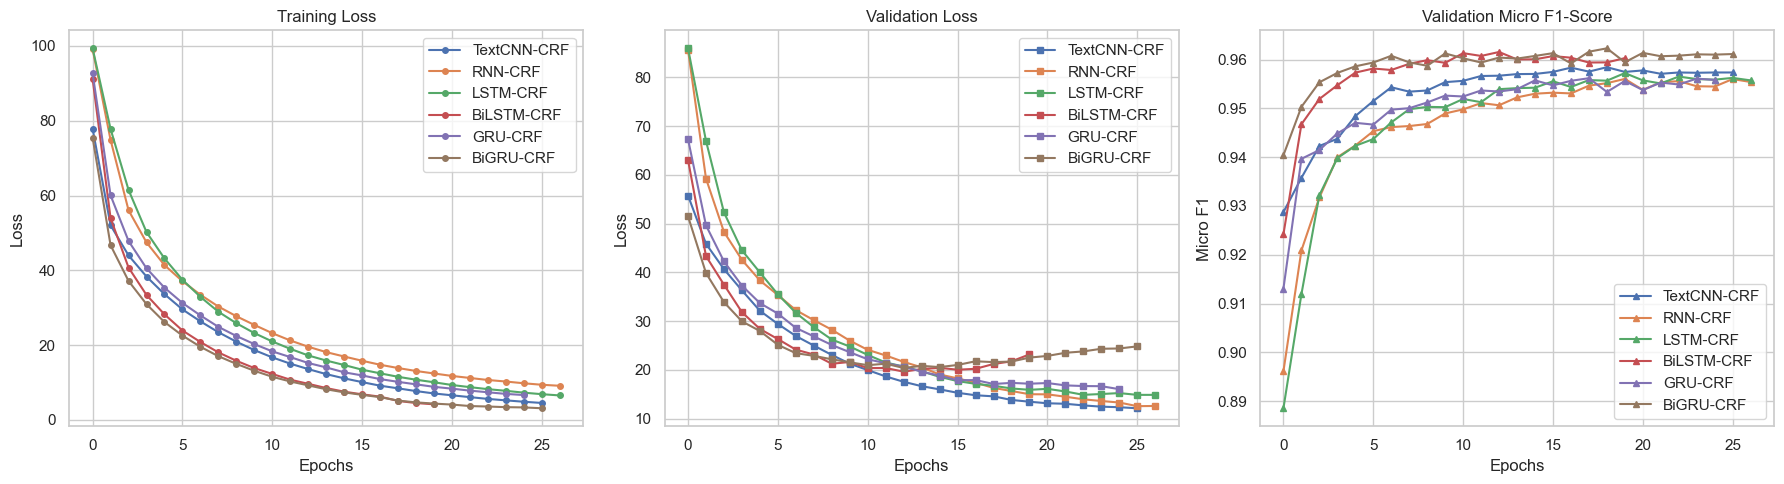

In [10]:
plt.figure(figsize=(18, 5))

# Plot 1: Training Loss
plt.subplot(1, 3, 1)
for name, hist in histories.items():
    plt.plot(hist['train_loss'], label=name, marker='o', markersize=4)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Validation Loss
plt.subplot(1, 3, 2)
for name, hist in histories.items():
    plt.plot(hist['dev_loss'], label=name, marker='s', markersize=4)
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot 3: Validation F1 Score
plt.subplot(1, 3, 3)
for name, hist in histories.items():
    plt.plot(hist['dev_f1'], label=name, marker='^', markersize=4)
plt.title('Validation Micro F1-Score')
plt.xlabel('Epochs')
plt.ylabel('Micro F1')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=300)
plt.show()

In [11]:
all_results = {}

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"📊 {name}")
    print(f"{'='*70}")
    
    # Dự đoán trên tập Test
    test = predict_all(model, test_loader)
    mt = evaluate_multilabel(test['true_sent'], test['pred_sent'], LABEL_NAMES)
    
    # Lưu lại để xuất bảng so sánh
    all_results[name] = {'metrics': mt, 'tok_acc': test['tok_acc']}
    
    print(f"\n  Token Accuracy: {test['tok_acc']:.4f}")
    print(f"  Total spans predicted: {sum(len(s) for s in test['pred_spans'])}")
    
    # In điểm số chung (Micro, Macro, Weighted Averaged)
    print(f"\n  {'Avg':<15} {'P':>8} {'R':>8} {'F1':>8}")
    print(f"  {'-'*42}")
    for avg in ['micro', 'macro', 'weighted']:
        m = mt[avg]
        print(f"  {avg:<15} {m['precision']:>8.4f} {m['recall']:>8.4f} {m['f1']:>8.4f}")
    
    # Báo cáo kết quả cụ thể theo từng nhãn một
    print(f"\n  {'Label':<25} {'P':>7} {'R':>7} {'F1':>7} {'Sup':>6}")
    print(f"  {'-'*55}")
    for ln in LABEL_NAMES:
        m = mt[ln]
        flag = '🔴' if m['support'] < 20 else '' # Cảnh báo khi thiếu lượng mẫu (support)
        print(f"  {ln:<25} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f} {m['support']:>6d} {flag}")
    
    # Xem ví dụ về những phân đoạn mô hình bôi đen (Span Examples) trên một số câu thử nghiệm
    print(f"\n  🔍 Span Examples (Top 3 samples):")
    for i in range(min(3, len(test_texts))):
        words = test_texts[i].lower().split()[:MAX_LEN]
        spans = test['pred_spans'][i]
        true = [LABEL_NAMES[j] for j in range(NUM_LABELS) if test['true_sent'][i][j]==1]
        
        # In tên văn bản và nhãn chuẩn thật sự (true label)
        print(f"  Text: \"{test_texts[i][:80]}...\"")
        print(f"  True: {true}")
        
        # In các dự đoán top 5 do model này trích xuất ra
        for label, s, e in spans[:5]:
            span_text = ' '.join(words[s:e])
            print(f"    → [{label}] \"{span_text}\"")
        print()

# ============================================================
# TỔNG KẾT VÀ SO SÁNH CUỐI CÙNG QUA BẢNG:
# ============================================================
print("\n" + "="*70)
print("  📊 FINAL LEADERBOARD — ALL BASELINES MODELS")
print("="*70)

print(f"\n  {'Model':<15} {'Micro F1':>9} {'Macro F1':>9} {'Wt F1':>9} │ {'TokAcc':>8}")
print(f"  {'─'*55}")

for name in models:
    r = all_results[name]
    mt = r['metrics']
    print(f"  {name:<15} {mt['micro']['f1']:>9.4f} {mt['macro']['f1']:>9.4f} "
          f"{mt['weighted']['f1']:>9.4f} │ {r['tok_acc']:>8.4f}")

best_model_name = max(all_results, key=lambda x: all_results[x]['metrics']['micro']['f1'])
print(f"\n  🏆 Best Baseline: {best_model_name} (Micro F1={all_results[best_model_name]['metrics']['micro']['f1']:.4f})")



📊 TextCNN-CRF

  Token Accuracy: 0.6772
  Total spans predicted: 7156

  Avg                    P        R       F1
  ------------------------------------------
  micro             0.7851   0.7866   0.7858
  macro             0.6240   0.5439   0.5541
  weighted          0.7776   0.7866   0.7776

  Label                           P       R      F1    Sup
  -------------------------------------------------------
  CAMERA#POSITIVE            0.8288  0.8815  0.8543    346 
  CAMERA#NEUTRAL             0.6607  0.4933  0.5649     75 
  CAMERA#NEGATIVE            0.6863  0.8000  0.7388    175 
  FEATURES#POSITIVE          0.7368  0.7521  0.7444    242 
  FEATURES#NEUTRAL           0.3571  0.1562  0.2174     32 
  FEATURES#NEGATIVE          0.7799  0.8371  0.8075    491 
  PERFORMANCE#POSITIVE       0.8557  0.8669  0.8613    691 
  PERFORMANCE#NEUTRAL        0.4615  0.2338  0.3103     77 
  PERFORMANCE#NEGATIVE       0.6987  0.8182  0.7537    462 
  DESIGN#POSITIVE            0.8848  0.8592  

In [12]:
os.makedirs(SAVE_DIR, exist_ok=True)
for name, model in models.items():
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'{name.lower().replace("-","_")}.pt'))
w2v.save(os.path.join(SAVE_DIR, 'word2vec.model'))
with open(os.path.join(SAVE_DIR, 'results.json'), 'w') as f:
    json.dump({name: {'micro_f1': r['metrics']['micro']['f1']} for name, r in all_results.items()}, f, indent=2)
print("All models successfully saved!")

All models successfully saved!
